# 11단계. 검증 구간 평가 (1회)

- 검증 구간: 2026-07-01 ~ 2026-08-31. **이 노트북에서 처음이자 마지막으로 본다.** 결과를 보고 모델·환산표·등급을 바꾸지 않는다.
- 평가 전에 고정한 설정(2026-09-29)
  - 모델: `outputs/model/vol_resid_model.joblib`(M3, 트리 100개, 학습 2024-04-01 ~ 2026-06-23)
  - 점수 환산표: `score_reference.csv`(D 방식)
  - 등급: 5등급(20점 단위)
  - 평활화: 종목별 최근 3일 예측 MDD_5 평균을 같은 환산표로 점수화
- 데이터: 4·5단계와 같은 함수(`compute_targets`, `features.build_all`)로 2026-09-16까지 다시 만든다. 학습 구간 값이 기존 캐시와 같은지 먼저 대조한다.
- 산출물: `outputs/model_report.md`, `outputs/model/grade_table_s3.csv`, `data/cache/validation_predictions.parquet`

In [1]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.data import load_table
from src.universe import load_calendar, load_membership, build_universe
from src.target import compute_targets
from src import features as F
from src.modeling import TARGET, build_dataset, evaluate_predictions, calibration_table, linear_matrix
from src.evaluate import daily_ic
from src.scoring import to_score, to_grade, GRADE_EDGES, GRADE_LABELS
from src import plotting as P
from sklearn.linear_model import Ridge

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
P.setup()

S, TRAIN_END, VAL_START, VAL_END, DATA_END = "2024-01-01", "2026-06-30", "2026-07-01", "2026-08-31", "2026-09-16"
MODEL = ROOT / "outputs" / "model"
model = joblib.load(MODEL / "vol_resid_model.joblib")
ref_tab = pd.read_csv(MODEL / "score_reference.csv")
REF = -ref_tab["pred_mdd5"].to_numpy()          # 위험(= -예측 낙폭) 오름차순
assert np.all(np.diff(REF) >= 0)
SMOOTH = 3

def smooth_pred(d, k=SMOOTH, col="pred"):
    """종목별 최근 k행(당일 포함) 예측 평균. 과거 값만 쓰므로 누수 없음."""
    d = d.sort_values(["symbol", "trade_date"]).copy()
    d[f"{col}_s"] = d.groupby("symbol")[col].transform(lambda s: s.rolling(k, min_periods=1).mean())
    return d

def grade_stats(d, score="score", pred="pred", by="grade"):
    return d.groupby(by, observed=True).agg(
        비중=(score, lambda s: len(s) / len(d)), 예상_낙폭=(pred, "mean"), 실제_평균=(TARGET, "mean"),
        실제_중앙값=(TARGET, "median"), 실제_하위10=(TARGET, lambda s: s.quantile(0.10)),
        하락5_비율=(TARGET, lambda s: (s <= -0.05).mean()), 하락10_비율=(TARGET, lambda s: (s <= -0.10).mean()), n=(score, "size"))

## 1. 평가 전 고정: 3일 평활 기준 등급표 (학습 구간 교차검증 예측)

운영 등급은 3일 평균 점수로 매기기로 했으므로, 기준 등급표도 같은 방식으로 다시 만든다. 학습 구간의 교차검증 예측(`oof_final.parquet`, 표본 밖)만 쓴다. 검증 데이터를 읽기 전에 저장한다.

In [2]:
oof = pd.read_parquet(ROOT / "data" / "cache" / "oof_final.parquet")
oof = smooth_pred(oof)
oof["score"] = to_score(oof.pred_s, REF)
oof["grade"] = to_grade(oof.score)
gt_cv = grade_stats(oof, pred="pred_s")
gt_cv.insert(0, "점수", [f"{a} ~ {b}" for a, b in zip(GRADE_EDGES[:-1], GRADE_EDGES[1:])])
gt_cv.reset_index().rename(columns={"grade": "등급"}).to_csv(MODEL / "grade_table_s3.csv", index=False, encoding="utf-8-sig")
meta = json.loads((MODEL / "model_meta.json").read_text(encoding="utf-8"))
meta["smoothing"] = {"days": SMOOTH, "rule": "종목별 최근 3거래일 예측 MDD_5 평균을 score_reference로 점수화", "grade_table": "grade_table_s3.csv", "decided": "2026-09-29"}
(MODEL / "model_meta.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
gt_cv.round(4)

,점수,비중,예상_낙폭,실제_평균,실제_중앙값,실제_하위10,하락5_비율,하락10_비율,n
grade,,,,,,,,,
매우 낮음,0 ~ 20,0.2080,-0.0252,-0.0261,-0.0204,-0.0578,0.1411,0.0174,17960
낮음,20 ~ 40,0.1982,-0.0332,-0.0334,-0.0270,-0.0720,0.2282,0.0371,17111
보통,40 ~ 60,0.1930,-0.0402,-0.0397,-0.0323,-0.0860,0.3085,0.0637,16663
높음,60 ~ 80,0.1999,-0.0488,-0.0495,-0.0412,-0.1077,0.4138,0.1206,17256
매우 높음,80 ~ 100,0.2008,-0.0647,-0.0681,-0.0567,-0.1504,0.5515,0.2498,17339


## 2. 검증 구간 데이터 구성

- 유니버스: 거래일 ~ 2026-09-16, 구성종목 스냅샷은 2026-08-31 이하만 쓴다.
- 타깃: KRX 일봉으로 `compute_targets`. 사용 표본 = 타깃 있음 & t일 정지 아님 & t+1..t+5에 정지 없음(학습과 같은 규칙).
- 변수: `build_all`을 2024-01-01 ~ 2026-09-16 데이터로 다시 실행한다(변수는 t일까지만 쓰므로 뒤 데이터가 앞 값을 바꾸지 않는다).

In [3]:
cal = load_calendar("2024-01-02", DATA_END)
mem = load_membership(VAL_END)
uni = build_universe(cal, mem)
c = load_table("krx_daily_candles", S, DATA_END)
vol_all = load_table("stock_daily_candles", S, DATA_END)[["symbol", "trade_date", "volume"]]
idx = load_table("market_indicator_daily_candles", S, DATA_END)
FLOW_TABLES = ["stock_investor_trading", "stock_institution_breakdown", "stock_program_trades", "stock_short_selling",
               "stock_credit_trades", "stock_securities_lending", "market_indicator_investor_trading"]
flows = {t: load_table(t, S, DATA_END) for t in FLOW_TABLES}
industry = pd.read_parquet(ROOT / "data" / "cache" / "stocks_industry.parquet").set_index("symbol")["industry"]
feat, _, _ = F.build_all(c, idx, uni, flows, industry, clean=False, vol_all=vol_all)
print(f"거래일 {len(cal)}일 ({cal.min().date()} ~ {cal.max().date()}), 변수 행 {len(feat):,}")

거래일 660일 (2024-01-02 ~ 2026-09-16), 변수 행 132,061


In [4]:
# 파이프라인 대조: 학습 구간 변수가 5단계 캐시와 같은가
old = pd.read_parquet(ROOT / "data" / "cache" / "features_train.parquet").set_index(["symbol", "trade_date"]).sort_index()
new = feat[feat.trade_date <= TRAIN_END].set_index(["symbol", "trade_date"]).sort_index()
assert old.index.equals(new.index), "유니버스 행이 다르다"
cols = [k for k in old.columns if k in new.columns and old[k].dtype != object]
diff = {k: int((~((old[k].astype(float) - new[k].astype(float)).abs().le(1e-9) | (old[k].isna() & new[k].isna()))).sum()) for k in cols}
diff = {k: v for k, v in diff.items() if v}
print(f"학습 구간 변수 {len(cols)}개 × {len(old):,}행 대조 → 다른 값:", diff if diff else "없음")

학습 구간 변수 232개 × 121,261행 대조 → 다른 값: 없음


In [5]:
tg = compute_targets(c)
halted = c.set_index(["symbol", "trade_date"])["halted"].astype(bool)
tg["halted"] = halted.reindex(pd.MultiIndex.from_frame(tg[["symbol", "trade_date"]])).fillna(False).to_numpy()
tg["halt_excluded"] = tg["halted"] | tg["halt_in_window"].fillna(False)
tg["use"] = tg["mdd_low"].notna() & ~tg["halt_excluded"]
# 학습 구간 타깃도 4단계 캐시와 대조
t_old = pd.read_parquet(ROOT / "data" / "cache" / "target_train.parquet")
chk = t_old[t_old.use].merge(tg[["symbol", "trade_date", "mdd_low", "use"]], on=["symbol", "trade_date"], suffixes=("", "_new"))
print(f"학습 구간 사용 표본 {int(t_old.use.sum()):,}행 중 대조 {len(chk):,}행, 타깃 불일치 {int((chk.mdd_low - chk.mdd_low_new).abs().gt(1e-12).sum())}, use 불일치 {int((~chk.use_new).sum())}")

u_val = uni[(uni.trade_date >= VAL_START) & (uni.trade_date <= VAL_END)]
val_t = u_val.merge(tg, on=["symbol", "trade_date"], how="left")
val_t["use"] = val_t["use"].fillna(False).astype(bool)
print(f"검증 구간 (날짜, 종목) {len(val_t):,}쌍, {val_t.trade_date.nunique()}거래일 | 타깃 없음 {int(val_t.mdd_low.isna().sum())}, "
      f"정지 관련 제외 {int((val_t.halt_excluded.fillna(False) & val_t.mdd_low.notna()).sum())} → 사용 {int(val_t.use.sum()):,}")

학습 구간 사용 표본 107,880행 중 대조 107,880행, 타깃 불일치 0, use 불일치 0
검증 구간 (날짜, 종목) 8,400쌍, 42거래일 | 타깃 없음 0, 정지 관련 제외 22 → 사용 8,378


## 3. 예측 (1회)

운영과 같게, 각 날짜의 **유니버스 전체**로 예측하고(같은 날 순위 계산), 종목별 최근 3일 평균을 낸다. 7월 초의 평활화를 위해 6월 말 예측부터 계산한다(변수만 쓰므로 누수 없음). 비교용 B1(`gk_5` 선형)은 학습 구간 전체로 다시 적합한다.

In [6]:
fx = feat.copy()
fx["abs_ret_20"] = fx["ret_20"].abs()
pr = fx[(fx.trade_date >= "2026-06-15") & (fx.trade_date <= VAL_END)].reset_index(drop=True)
parts = model.predict_parts(pr)
pr[["level", "cs_adj", "pred"]] = parts[["level", "cs_adj", "pred"]].to_numpy()
pr = smooth_pred(pr)
# B1 베이스라인: 학습 표본 전체로 gk_5 선형
ds = pd.read_parquet(ROOT / "data" / "cache" / "model_dataset.parquet")
Xtr, Xte = linear_matrix(ds, pr, ["gk_5"])
pr["pred_b1"] = Ridge(alpha=1.0).fit(Xtr, ds[TARGET]).predict(Xte)

v = pr[(pr.trade_date >= VAL_START)].merge(val_t[["symbol", "trade_date", "use", TARGET, "mdd_close"]], on=["symbol", "trade_date"], how="left")
v["score_raw"] = to_score(v.pred, REF)
v["score"] = to_score(v.pred_s, REF)
v["grade"] = to_grade(v.score)
v.to_parquet(ROOT / "data" / "cache" / "validation_predictions.parquet", index=False)
ve = v[v.use].copy()
print(f"예측 {len(v):,}행 (결측 예측 {int(v.pred.isna().sum())}), 평가 표본 {len(ve):,}행 {ve.trade_date.nunique()}거래일 {ve.symbol.nunique()}종목")

예측 8,400행 (결측 예측 0), 평가 표본 8,378행 42거래일 200종목


## 4. 성능: 교차검증 대비

In [7]:
def summary(d, pred):
    e = evaluate_predictions(d, pred=pred)
    return {"풀링 Spearman": d[[pred, TARGET]].corr("spearman").iloc[0, 1], "날짜별 IC": e["IC"], "IC IR": e["IC_IR"],
            "수준 상관": e["level_corr"], "수준 편향": e["level_bias"], "MAE": e["MAE"],
            "상위10% -10%하락 비율": e["top10_event_rate"], "-10%하락 포착률": e["top10_event_capture"], "n": e["n"]}

rows = {
    "교차검증 M3 (전체)": summary(oof, "pred"),
    "교차검증 M3 (fold 5)": summary(oof[oof.fold == 5], "pred"),
    "검증 M3 (매일)": summary(ve, "pred"),
    "검증 M3 (3일 평균)": summary(ve, "pred_s"),
    "검증 B1 gk_5": summary(ve, "pred_b1"),
}
perf = pd.DataFrame(rows).T
perf.round(4)

,풀링 Spearman,날짜별 IC,IC IR,수준 상관,수준 편향,MAE,상위10% -10%하락 비율,-10%하락 포착률,n
교차검증 M3 (전체),0.3213,0.3393,1.7816,0.4220,0.0009,0.0296,0.3119,0.3198,86329.0
교차검증 M3 (fold 5),0.3063,0.3558,1.6725,0.3130,0.0111,0.0415,0.4454,0.2165,21592.0
검증 M3 (매일),0.3403,0.4584,1.5147,-0.1434,0.0002,0.0411,0.4105,0.1934,8378.0
검증 M3 (3일 평균),0.3400,0.4558,1.4921,-0.1383,-0.0001,0.0412,0.4129,0.1945,8378.0
검증 B1 gk_5,0.2684,0.4270,1.4888,-0.1634,0.0057,0.0415,0.3759,0.1771,8378.0


In [8]:
# 날짜별 IC 분포와 월별
ic = daily_ic(ve, ["pred", "pred_s", "pred_b1"], TARGET)
print("IC > 0 인 날 비율:", (ic > 0).mean().round(3).to_dict())
ic.groupby(ic.index.to_period("M")).mean().round(4)

IC > 0 인 날 비율: {'pred': 0.881, 'pred_s': 0.881, 'pred_b1': 0.905}


,pred,pred_s,pred_b1
trade_date,,,
2026-07,0.5641,0.5649,0.5383
2026-08,0.3420,0.3358,0.3046


## 5. 등급별 실제 결과 (3일 평균 점수)

In [9]:
gt_val = grade_stats(ve, pred="pred_s")
cmp_ = pd.DataFrame({
    "비중(CV)": gt_cv["비중"], "비중(검증)": gt_val["비중"],
    "예상(검증)": gt_val["예상_낙폭"], "실제평균(CV)": gt_cv["실제_평균"], "실제평균(검증)": gt_val["실제_평균"],
    "-10%비율(CV)": gt_cv["하락10_비율"], "-10%비율(검증)": gt_val["하락10_비율"], "n(검증)": gt_val["n"]})
display(gt_val.round(4))
cmp_.round(4)

,비중,예상_낙폭,실제_평균,실제_중앙값,실제_하위10,하락5_비율,하락10_비율,n
grade,,,,,,,,
매우 낮음,0.0073,-0.0263,-0.0148,-0.0122,-0.0265,0.0000,0.0000,61
낮음,0.0246,-0.0340,-0.0267,-0.0237,-0.0499,0.0971,0.0097,206
보통,0.0757,-0.0406,-0.0330,-0.0275,-0.0677,0.1972,0.0268,634
높음,0.1702,-0.0496,-0.0442,-0.0389,-0.0872,0.3612,0.0561,1426
매우 높음,0.7222,-0.0726,-0.0749,-0.0609,-0.1609,0.5771,0.2776,6051


,비중(CV),비중(검증),예상(검증),실제평균(CV),실제평균(검증),-10%비율(CV),-10%비율(검증),n(검증)
grade,,,,,,,,
매우 낮음,0.2080,0.0073,-0.0263,-0.0261,-0.0148,0.0174,0.0000,61
낮음,0.1982,0.0246,-0.0340,-0.0334,-0.0267,0.0371,0.0097,206
보통,0.1930,0.0757,-0.0406,-0.0397,-0.0330,0.0637,0.0268,634
높음,0.1999,0.1702,-0.0496,-0.0495,-0.0442,0.1206,0.0561,1426
매우 높음,0.2008,0.7222,-0.0726,-0.0681,-0.0749,0.2498,0.2776,6051


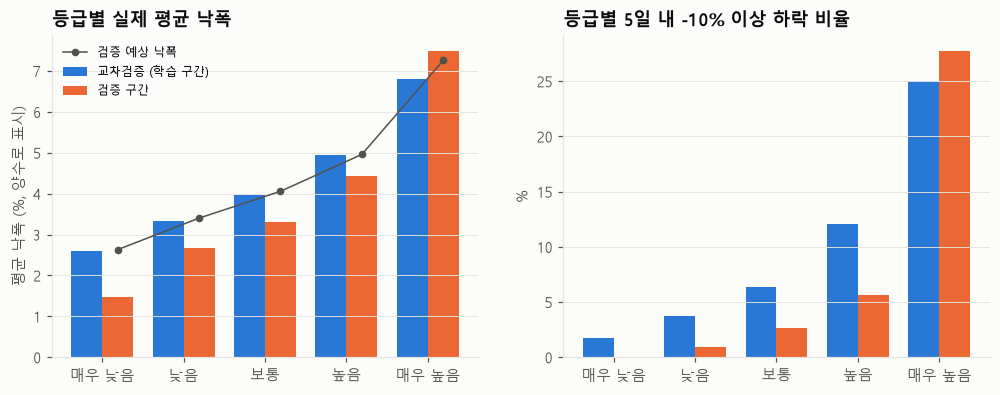

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
x = np.arange(len(GRADE_LABELS))
w = 0.38
axes[0].bar(x - w / 2, -gt_cv["실제_평균"] * 100, w, color=P.SERIES[0], label="교차검증 (학습 구간)")
axes[0].bar(x + w / 2, -gt_val["실제_평균"].reindex(GRADE_LABELS) * 100, w, color=P.SERIES[1], label="검증 구간")
axes[0].plot(x + w / 2, -gt_val["예상_낙폭"].reindex(GRADE_LABELS) * 100, color=P.TEXT_2, marker="o", ms=4, lw=1, label="검증 예상 낙폭")
axes[0].set_ylabel("평균 낙폭 (%, 양수로 표시)")
axes[0].set_title("등급별 실제 평균 낙폭")
axes[1].bar(x - w / 2, gt_cv["하락10_비율"] * 100, w, color=P.SERIES[0])
axes[1].bar(x + w / 2, gt_val["하락10_비율"].reindex(GRADE_LABELS) * 100, w, color=P.SERIES[1])
axes[1].set_ylabel("%")
axes[1].set_title("등급별 5일 내 -10% 이상 하락 비율")
for ax in axes:
    ax.set_xticks(x, GRADE_LABELS)
    ax.grid(axis="x", visible=False)
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
P.save(fig, "11_grade_validation")
plt.show()

In [11]:
# 예측 분위(검증 구간 내부 10분위)별 보정
cal_v = calibration_table(ve, pred="pred_s")
cal_v.round(4)

,bucket,pred_mean,actual_mean,event_rate,n
0,1,-0.0377,-0.0297,0.0191,838
1,2,-0.0471,-0.0412,0.0430,838
2,3,-0.0528,-0.0493,0.0871,838
3,4,-0.0576,-0.0525,0.1243,837
4,5,-0.0621,-0.0580,0.1659,838
5,6,-0.0668,-0.0674,0.2291,838
6,7,-0.0720,-0.0805,0.3106,837
7,8,-0.0772,-0.0849,0.3282,838
8,9,-0.0833,-0.0925,0.4033,838
9,10,-0.0929,-0.0931,0.4129,838


## 6. 수준: 날짜 평균 예측 vs 실제

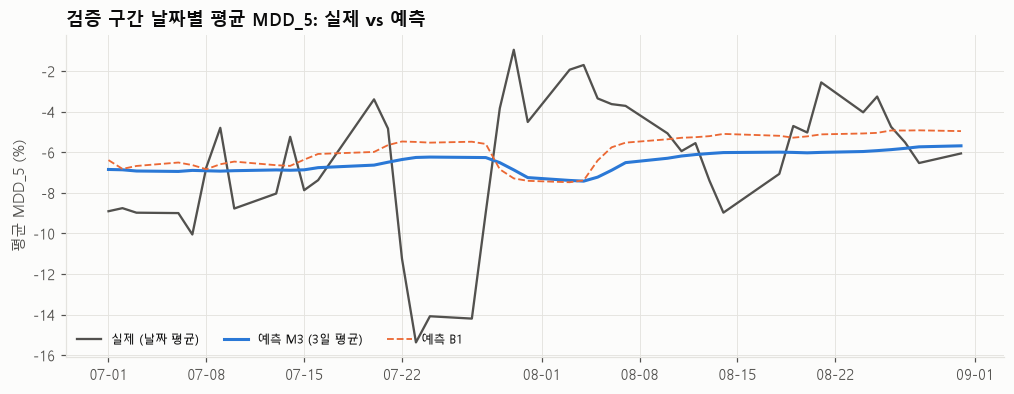

검증 구간 KOSPI 수익률 -19.5%, 일간 변동성 0.0509 (학습 구간 0.0206)
날짜 평균: 실제 -0.0649 | 예측 M3 -0.065 | B1 -0.0592
학습 구간 평균 실제 MDD_5: -0.0427


In [12]:
dm = ve.groupby("trade_date").agg(actual=(TARGET, "mean"), pred=("pred_s", "mean"), pred_raw=("pred", "mean"), b1=("pred_b1", "mean"))
idx_k = idx[idx.symbol == "KOSPI"].set_index("trade_date").close_price
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(dm.index, dm.actual * 100, color=P.TEXT_2, lw=1.5, label="실제 (날짜 평균)")
ax.plot(dm.index, dm.pred * 100, color=P.SERIES[0], lw=2, label="예측 M3 (3일 평균)")
ax.plot(dm.index, dm.b1 * 100, color=P.SERIES[1], lw=1.2, ls="--", label="예측 B1")
ax.set_ylabel("평균 MDD_5 (%)")
ax.set_title("검증 구간 날짜별 평균 MDD_5: 실제 vs 예측")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.legend(frameon=False, fontsize=8, ncol=3, loc="lower left")
P.save(fig, "11_level_tracking")
plt.show()
kr = idx_k.pct_change()
print(f"검증 구간 KOSPI 수익률 {idx_k[VAL_END] / idx_k[idx_k.index < VAL_START].iloc[-1] - 1:.1%}, 일간 변동성 {kr[VAL_START:VAL_END].std():.4f} "
      f"(학습 구간 {kr['2024-04-01':TRAIN_END].std():.4f})")
print("날짜 평균: 실제", round(dm.actual.mean(), 4), "| 예측 M3", round(dm.pred.mean(), 4), "| B1", round(dm.b1.mean(), 4))
print("학습 구간 평균 실제 MDD_5:", round(ds[TARGET].mean(), 4))

## 7. 등급 분포와 안정성

In [13]:
share = v.groupby([v.trade_date.dt.to_period("M"), "grade"], observed=True).size().unstack(fill_value=0)
display((share.div(share.sum(axis=1), axis=0)).round(3))
vs = v.sort_values(["symbol", "trade_date"])
chg = {}
for col in ["score_raw", "score"]:
    g = pd.Series(to_grade(vs[col]).codes, index=vs.index)
    dd = g.groupby(vs.symbol).diff().dropna()
    chg[col] = {"하루 등급 변경": (dd != 0).mean(), "2등급 이상 변경": (dd.abs() >= 2).mean()}
pd.DataFrame(chg).rename(columns={"score_raw": "매일", "score": "3일 평균"}).round(4)

grade,매우 낮음,낮음,보통,높음,매우 높음
trade_date,,,,,
2026-07,0.002,0.016,0.060,0.140,0.783
2026-08,0.014,0.034,0.096,0.203,0.654


,매일,3일 평균
하루 등급 변경,0.0799,0.0526
2등급 이상 변경,0.0016,0.0000


In [14]:
# 수준(level)과 횡단면 보정(cs_adj)의 기여: 날짜별 IC
ic_parts = daily_ic(ve, ["level", "cs_adj", "pred"], TARGET).mean()
ic_parts.round(4)

level     0.4473
cs_adj   -0.0365
pred      0.4584
dtype: float64

## 8. 요약

- **데이터 대조**: 다시 만든 학습 구간 변수 232개(121,261행)와 타깃(107,880행)이 기존 캐시와 모두 같다. 검증 표본은 8,378쌍(42거래일, 200종목)이고, 거래정지 관련 22쌍을 뺐다.
- **검증 구간은 강한 충격 국면이다.** KOSPI -19.5%, 일간 변동성 5.1%(학습 구간 2.1%), 평균 MDD_5 -6.5%(학습 구간 -4.3%).
- **종목 간 순위는 교차검증보다 좋다.**
  - 날짜별 IC 0.458(교차검증 0.339, fold 5 0.356), 풀링 Spearman 0.340(교차검증 0.321)
  - B1(`gk_5` 선형)보다 낫다: 풀링 0.340 vs 0.268, IC 0.458 vs 0.427
  - IC가 양수인 날은 88%다.
- **등급은 단조롭다.** 3일 평균 점수 기준 실제 평균 낙폭은 매우 낮음 -1.5% → 매우 높음 -7.5%, -10% 이상 하락 비율은 0% → 27.8%다.
- **등급 분포가 한쪽으로 몰렸다.** 종목-일의 72%가 '매우 높음'이다(7월 78%, 8월 65%). 과거 대비 수준을 나타내는 D 방식의 의도된 동작이지만, 이런 국면에서는 등급만으로 종목을 구분하기 어렵다.
- **낮은 등급은 위험을 과대평가했다.** 매우 낮음 ~ 높음 등급의 실제 평균 낙폭이 예상보다 0.5 ~ 1.1%p 작다. 매우 높음 등급은 실제(-7.5%)가 예상(-7.3%)보다 조금 크다.
- **날짜별 수준은 따라가지 못한다.** 기간 평균은 맞았지만(예측 -6.5%, 실제 -6.5%), 날짜별 상관은 -0.14다. 7월 22 ~ 27일의 급락(날짜 평균 -14 ~ -15%)은 미리 반영하지 못했다. 이미 알던 한계다.
- **횡단면 보정(LightGBM)의 기여가 작다.** 순위 성능은 대부분 변동성 수준 부분에서 나온다(IC 0.447). 보정값 단독 IC는 -0.04이고, 합치면 IC가 0.011 오른다.
- **안정성**: 3일 평균을 쓰면 하루 등급 변경 비율이 8.0%에서 5.3%로 줄고, 2등급 이상 변경은 없다.
